## Экстрактим фичи из картинок при помощи [SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html)

In [32]:
import sys
sys.path.append('../..')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split

In [34]:
train = pd.read_csv('../../data/01_raw/train_images.csv')
test = pd.read_csv('../../data/01_raw/test_images.csv')

In [35]:
path_to_dataset = Path("../../data/01_raw/sneakers-dataset")

In [36]:
import cv2 as cv

img_path = 'reebok_classic_leather/0004.jpg'
img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
img

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(140, 105), dtype=uint8)

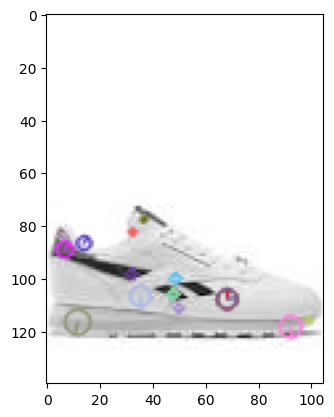

In [37]:
# Для каждого изображения в датафрейме считаем SIFT
sift = cv.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(img, None)
img_with_keypoints = cv.drawKeypoints(img, keypoints, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_with_keypoints)

In [38]:
descriptors

array([[  0.,   1., 141., ...,   0.,   2.,   4.],
       [  0.,   0.,   0., ...,   0.,   0.,   1.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       ...,
       [  6.,  87., 102., ...,  25., 123.,   6.],
       [  0.,   0.,   0., ...,   0.,   0.,   5.],
       [  0.,   1.,  11., ...,   0.,   0., 132.]],
      shape=(17, 128), dtype=float32)

In [39]:
feature_df = []
for img_path in train['path']:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    feature_df.append(descriptors)
feature_df = pd.concat(feature_df)
feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,0.0,0.0,0.0,0.0,79.0,144.0,1.0,0.0,102.0,22.0,...,13.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,nike_air_force_1_high/0036.jpg
1,0.0,1.0,25.0,14.0,1.0,0.0,0.0,0.0,0.0,11.0,...,36.0,31.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,nike_air_force_1_high/0036.jpg
2,36.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,137.0,2.0,...,17.0,9.0,36.0,3.0,7.0,74.0,26.0,0.0,0.0,nike_air_force_1_high/0036.jpg
3,19.0,0.0,0.0,0.0,0.0,0.0,0.0,54.0,60.0,0.0,...,1.0,75.0,18.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_force_1_high/0036.jpg
4,13.0,2.0,2.0,7.0,1.0,0.0,2.0,26.0,172.0,4.0,...,9.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_force_1_high/0036.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,4.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,150.0,53.0,...,88.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_force_1_low/0137.jpg
38,35.0,92.0,0.0,0.0,0.0,0.0,0.0,2.0,87.0,156.0,...,156.0,16.0,1.0,0.0,0.0,0.0,0.0,1.0,11.0,nike_air_force_1_low/0137.jpg
39,0.0,0.0,2.0,19.0,15.0,57.0,30.0,0.0,138.0,16.0,...,7.0,78.0,36.0,0.0,0.0,0.0,0.0,0.0,3.0,nike_air_force_1_low/0137.jpg
40,5.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,113.0,1.0,...,65.0,59.0,1.0,0.0,0.0,0.0,0.0,0.0,7.0,nike_air_force_1_low/0137.jpg


In [40]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

feature_df[list(range(128))] = scaler.fit_transform(feature_df[list(range(128))])
n_feats = 200
clustering = KMeans(n_feats)
clustering.fit(feature_df[list(range(128))])
feature_df['cluster_feat'] = clustering.predict(feature_df[list(range(128))]).astype(str)

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

invalid value encountered in matmul



[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 0.267s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 3.063638


/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning:

invalid value encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning:

invalid value encountered in matmul

/Users

[t-SNE] KL divergence after 250 iterations with early exaggeration: 94.307098
[t-SNE] KL divergence after 1000 iterations: 2.642727


/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_47969/2451772772.py:9: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_47969/2451772772.py:9: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



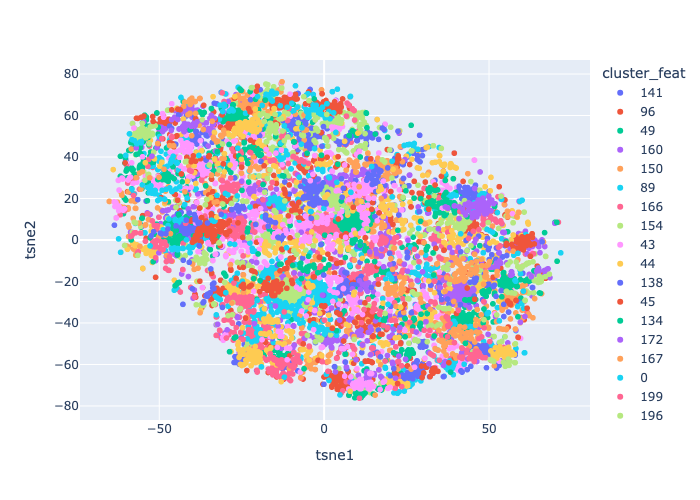

In [41]:
from sklearn.manifold import TSNE
import plotly.express as px
from IPython.display import Image, display


# Assume X is your high-dimensional data matrix and y are labels or target classes
tsne = TSNE(n_components=2, random_state=123, verbose=1)
sample_df = feature_df.sample(10000, random_state=0)
sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])
fig = px.scatter(sample_df, x='tsne1', y='tsne2', color='cluster_feat')
display(Image(fig.to_image('png')))

In [42]:
train.set_index('path', inplace=True)


In [43]:
test.set_index('path', inplace=True)

In [44]:
test_feature_df = []
for img_path in test.index:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    test_feature_df.append(descriptors)
test_feature_df = pd.concat(test_feature_df)
test_feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,33.0,19.0,7.0,3.0,19.0,16.0,27.0,22.0,4.0,3.0,...,37.0,0.0,1.0,0.0,0.0,30.0,9.0,0.0,1.0,adidas_forum_low/0026.jpg
1,1.0,7.0,6.0,0.0,4.0,39.0,27.0,3.0,48.0,1.0,...,4.0,54.0,1.0,1.0,2.0,1.0,1.0,2.0,3.0,adidas_forum_low/0026.jpg
2,0.0,0.0,154.0,154.0,0.0,0.0,0.0,1.0,2.0,1.0,...,10.0,2.0,4.0,18.0,13.0,6.0,5.0,38.0,62.0,adidas_forum_low/0026.jpg
3,148.0,23.0,0.0,0.0,0.0,0.0,24.0,38.0,148.0,42.0,...,14.0,7.0,11.0,8.0,4.0,20.0,1.0,0.0,3.0,adidas_forum_low/0026.jpg
4,0.0,3.0,34.0,8.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,35.0,93.0,3.0,0.0,0.0,0.0,0.0,0.0,adidas_forum_low/0026.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,1.0,0.0,0.0,0.0,6.0,32.0,42.0,30.0,7.0,0.0,...,19.0,5.0,0.0,0.0,0.0,0.0,0.0,6.0,15.0,nike_cortez/0130.jpg
13,0.0,98.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,61.0,...,131.0,47.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,nike_cortez/0130.jpg
14,0.0,1.0,31.0,141.0,7.0,0.0,0.0,0.0,89.0,67.0,...,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nike_cortez/0130.jpg
15,43.0,105.0,34.0,5.0,0.0,0.0,0.0,0.0,11.0,122.0,...,36.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,nike_cortez/0130.jpg


In [45]:
test_feature_df[list(range(128))] = scaler.transform(test_feature_df[list(range(128))])
test_feature_df['cluster_feat'] = clustering.predict(test_feature_df[list(range(128))]).astype(str)

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_47969/89987943.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [46]:
train[list(range(n_feats))] = 0
for i, row in tqdm(feature_df.iterrows()):
    train.loc[row['path'], int(row['cluster_feat'])] += 1
train

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_47969/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_47969/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_47969/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.conca

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
nike_air_force_1_high/0036.jpg,nike_air_force_1_high,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
nike_air_jordan_1_high/0026.jpg,nike_air_jordan_1_high,1,0,0,1,1,0,0,0,0,...,2,0,0,1,0,0,0,0,0,0
converse_one_star/0025.jpg,converse_one_star,0,0,1,0,0,1,0,0,0,...,0,3,0,0,5,0,1,0,0,0
reebok_classic_leather/0004.jpg,reebok_classic_leather,0,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
nike_air_jordan_11/0014.jpg,nike_air_jordan_11,0,0,1,1,1,0,0,0,0,...,1,0,1,0,0,0,2,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_max_1/0052.jpg,nike_air_max_1,3,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,1,0,0,1
nike_air_force_1_low/0102.jpg,nike_air_force_1_low,1,1,0,0,2,0,0,0,0,...,0,3,0,0,1,0,0,0,0,0
adidas_stan_smith/0073.jpg,adidas_stan_smith,1,2,0,0,3,1,0,0,0,...,0,0,0,0,0,0,0,0,0,3


In [47]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()

train[list(range(n_feats))] = tfidf.fit_transform(train[list(range(n_feats))]).toarray()
train

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
nike_air_force_1_high/0036.jpg,nike_air_force_1_high,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.122315,0.0,0.0,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
nike_air_jordan_1_high/0026.jpg,nike_air_jordan_1_high,0.074594,0.000000,0.000000,0.096803,0.069483,0.000000,0.000000,0.0,0.0,...,0.187555,0.000000,0.00000,0.091174,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
converse_one_star/0025.jpg,converse_one_star,0.000000,0.000000,0.122772,0.000000,0.000000,0.121901,0.000000,0.0,0.0,...,0.000000,0.422152,0.00000,0.000000,0.628905,0.000000,0.104751,0.000000,0.0,0.000000
reebok_classic_leather/0004.jpg,reebok_classic_leather,0.000000,0.000000,0.000000,0.000000,0.188403,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.00000,0.000000,0.224354,0.000000,0.000000,0.000000,0.0,0.000000
nike_air_jordan_11/0014.jpg,nike_air_jordan_11,0.000000,0.000000,0.055081,0.066021,0.047388,0.000000,0.000000,0.0,0.0,...,0.063958,0.000000,0.05918,0.000000,0.000000,0.000000,0.093992,0.118183,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_max_1/0052.jpg,nike_air_max_1,0.353657,0.000000,0.000000,0.000000,0.000000,0.000000,0.110700,0.0,0.0,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.139822,0.108899,0.000000,0.0,0.113028
nike_air_force_1_low/0102.jpg,nike_air_force_1_low,0.141989,0.132641,0.000000,0.000000,0.264519,0.000000,0.000000,0.0,0.0,...,0.000000,0.528599,0.00000,0.000000,0.157497,0.000000,0.000000,0.000000,0.0,0.000000
adidas_stan_smith/0073.jpg,adidas_stan_smith,0.082165,0.153511,0.000000,0.000000,0.229604,0.088327,0.000000,0.0,0.0,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.236336


In [48]:
test[list(range(n_feats))] = 0
for i, row in tqdm(test_feature_df.iterrows()):
    test.loc[row['path'], int(row['cluster_feat'])] += 1
test

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_47969/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_47969/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_47969/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
adidas_forum_low/0026.jpg,adidas_forum_low,0,1,0,0,0,0,1,1,0,...,0,0,0,0,0,2,1,0,0,0
nike_air_jordan_4/0078.jpg,nike_air_jordan_4,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
yeezy_boost_350_v2/0018.jpg,yeezy_boost_350_v2,0,0,0,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
adidas_superstar/0028.jpg,adidas_superstar,0,1,1,1,0,0,2,0,0,...,0,0,0,0,0,0,1,0,1,2
adidas_forum_high/0091.jpg,adidas_forum_high,0,2,1,0,1,1,1,0,0,...,2,0,1,2,0,2,0,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_vapormax_flyknit/0010.jpg,nike_air_vapormax_flyknit,2,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
nike_air_jordan_1_low/0015.jpg,nike_air_jordan_1_low,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
adidas_forum_high/0114.jpg,adidas_forum_high,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0


In [49]:
test[list(range(n_feats))] = tfidf.transform(test[list(range(n_feats))]).toarray()
test

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
adidas_forum_low/0026.jpg,adidas_forum_low,0.000000,0.050726,0.000000,0.000000,0.000000,0.000000,0.050991,0.074298,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.128810,0.050161,0.000000,0.000000,0.000000
nike_air_jordan_4/0078.jpg,nike_air_jordan_4,0.118430,0.000000,0.128222,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.113549
yeezy_boost_350_v2/0018.jpg,yeezy_boost_350_v2,0.000000,0.000000,0.000000,0.000000,0.139999,0.000000,0.141136,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.166713,0.000000,0.000000,0.000000,0.000000,0.000000
adidas_superstar/0028.jpg,adidas_superstar,0.000000,0.075272,0.087239,0.104566,0.000000,0.000000,0.151329,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.074434,0.000000,0.093766,0.154511
adidas_forum_high/0091.jpg,adidas_forum_high,0.000000,0.070739,0.040993,0.000000,0.035268,0.040702,0.035554,0.000000,0.0,...,0.095198,0.0,0.044043,0.092555,0.000000,0.089815,0.000000,0.131932,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_vapormax_flyknit/0010.jpg,nike_air_vapormax_flyknit,0.255659,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.160703,0.0,0.000000,0.000000,0.000000,0.000000,0.118085,0.000000,0.000000,0.000000
nike_air_jordan_1_low/0015.jpg,nike_air_jordan_1_low,0.000000,0.000000,0.000000,0.000000,0.176987,0.000000,0.178425,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
adidas_forum_high/0114.jpg,adidas_forum_high,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.103571,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.101886,0.000000,0.000000,0.000000


In [50]:
from sklearn.svm import LinearSVC, SVC

svc = LinearSVC(loss='squared_hinge', C=1, random_state=42)

# svc = SVC(C=1, kernel='poly')
svc.fit(train[list(range(n_feats))], train['sneaker_class'])

train['pred'] = svc.predict(train[list(range(n_feats))])
print(classification_report(train['sneaker_class'], train['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.42      0.55      0.48       118
                   adidas_forum_low       0.57      0.45      0.50        73
                     adidas_gazelle       0.48      0.56      0.52       119
                      adidas_nmd_r1       0.58      0.58      0.58        76
                       adidas_samba       0.65      0.59      0.62        59
                  adidas_stan_smith       0.44      0.47      0.46       118
                   adidas_superstar       0.60      0.51      0.55        74
                  adidas_ultraboost       0.48      0.58      0.52       119
                 asics_gel-lyte_iii       0.54      0.42      0.48        73
             converse_chuck_70_high       0.70      0.62      0.65        60
              converse_chuck_70_low       0.53      0.63      0.58       118
converse_chuck_taylor_all-star_high       0.69      0.74      0.71        6

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_47969/2046280357.py:8: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [51]:
test['pred'] = svc.predict(test[list(range(n_feats))])
print(classification_report(test['sneaker_class'], test['pred']))


                                     precision    recall  f1-score   support

                  adidas_forum_high       0.23      0.27      0.25        30
                   adidas_forum_low       0.21      0.17      0.19        18
                     adidas_gazelle       0.32      0.43      0.37        30
                      adidas_nmd_r1       0.30      0.37      0.33        19
                       adidas_samba       0.20      0.21      0.21        14
                  adidas_stan_smith       0.18      0.21      0.19        29
                   adidas_superstar       0.10      0.11      0.10        19
                  adidas_ultraboost       0.21      0.23      0.22        30
                 asics_gel-lyte_iii       0.08      0.06      0.06        18
             converse_chuck_70_high       0.18      0.13      0.15        15
              converse_chuck_70_low       0.25      0.33      0.29        30
converse_chuck_taylor_all-star_high       0.38      0.40      0.39        1

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_47969/1775051571.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [52]:
from sklearn.model_selection import cross_val_score

# 1 — 0.18
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='rbf')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.09447745787300525),
 np.float64(0.23123209835211841),
 np.float64(0.23705734107056503),
 np.float64(0.23705710858163148),
 np.float64(0.23705710858163148),
 np.float64(0.23705710858163148)]

In [53]:
Cs = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1, 10]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='poly', degree=3)
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.09512377710820966),
 np.float64(0.18032771640069933),
 np.float64(0.2051321932076033),
 np.float64(0.2232502882862776),
 np.float64(0.23252473682252725),
 np.float64(0.2385652642934196),
 np.float64(0.2385661942491537),
 np.float64(0.24072299408548153),
 np.float64(0.2353297158055277)]

In [54]:
Cs = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1, 10]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='poly', degree=2)
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.11043898560428525),
 np.float64(0.19801593944128257),
 np.float64(0.21678012126622775),
 np.float64(0.22907460104899008),
 np.float64(0.23360464791875907),
 np.float64(0.23727076591154264),
 np.float64(0.24309461369638807),
 np.float64(0.24697927128668679),
 np.float64(0.2323138693598185)]

In [55]:
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='linear')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.12273579027638284),
 np.float64(0.21872186883904327),
 np.float64(0.16910826544656474),
 np.float64(0.1686779284306067),
 np.float64(0.168893445671986),
 np.float64(0.168893445671986)]

In [56]:
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='sigmoid')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.12683480266339323),
 np.float64(0.20750590521891157),
 np.float64(0.16285384815682774),
 np.float64(0.15120545512033629),
 np.float64(0.1492657999479225),
 np.float64(0.14710783766692706)]

In [60]:
svc = SVC(C=1, kernel='poly', degree=2)
svc.fit(X, y)
test['pred'] = svc.predict(test[list(range(n_feats))])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.27      0.37      0.31        30
                   adidas_forum_low       0.29      0.11      0.16        18
                     adidas_gazelle       0.33      0.43      0.37        30
                      adidas_nmd_r1       0.37      0.37      0.37        19
                       adidas_samba       0.14      0.07      0.10        14
                  adidas_stan_smith       0.23      0.34      0.27        29
                   adidas_superstar       0.38      0.16      0.22        19
                  adidas_ultraboost       0.36      0.33      0.34        30
                 asics_gel-lyte_iii       0.17      0.06      0.08        18
             converse_chuck_70_high       0.60      0.20      0.30        15
              converse_chuck_70_low       0.29      0.37      0.32        30
converse_chuck_taylor_all-star_high       0.60      0.40      0.48        1

In [58]:
from sklearn.ensemble import RandomForestClassifier

X = train[list(range(n_feats))]
y = train['sneaker_class']

forest = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=5)
cross_val_score(forest, X, y)#.mean()

array([0.21228448, 0.21790723, 0.22977346, 0.22330097, 0.19309601])

In [59]:
from sklearn.ensemble import ExtraTreesClassifier

extra = ExtraTreesClassifier(n_estimators=1000, random_state=42)
cross_val_score(extra, X, y)#.mean()

array([0.21875   , 0.22006472, 0.23840345, 0.24595469, 0.21574973])